# Notebook 04 — Results Table + Learning Curves

**Run after Notebook 03.**

Produces:
1. Full 3×3 ablation table (3 models × 3 aug modes)
2. Aug gain comparison showing GIN contribution
3. Learning curves for all 9 experiments
4. Per-center breakdown
5. Comparison vs FedBCa centralized baseline

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path('.').resolve().parent
paths        = json.loads((PROJECT_ROOT / 'paths.json').read_text())
EXPERIMENTS  = Path(paths['experiments'])
FIGURES      = PROJECT_ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

print('Paths loaded.')

Paths loaded.


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Load all experiment results
# ─────────────────────────────────────────────
import torch

EXPERIMENTS_MAP = {
    'exp01_eff_noaug':       ('EfficientNet-B0', 'No Aug'),
    'exp02_eff_ginonly':     ('EfficientNet-B0', 'GIN Only'),
    'exp03_eff_fullaug':     ('EfficientNet-B0', 'Full Aug'),
    'exp04_res50_noaug':     ('ResNet50+CBAM',   'No Aug'),
    'exp05_res50_ginonly':   ('ResNet50+CBAM',   'GIN Only'),
    'exp06_res50_fullaug':   ('ResNet50+CBAM',   'Full Aug'),
    'exp07_medsam_noaug':    ('MedSAM ViT-B',    'No Aug'),
    'exp08_medsam_ginonly':  ('MedSAM ViT-B',    'GIN Only'),
    'exp09_medsam_fullaug':  ('MedSAM ViT-B',    'Full Aug'),
}

results = {}
for exp_name, (model, aug) in EXPERIMENTS_MAP.items():
    ckpt_path = EXPERIMENTS / exp_name / 'checkpoint_best.pt'
    if not ckpt_path.exists():
        print(f'  [skip] {exp_name} — not yet trained')
        continue
    ckpt = torch.load(str(ckpt_path), map_location='cpu')
    m    = ckpt['metrics']
    results[exp_name] = {
        'model':    model,
        'aug':      aug,
        'dsc':      m.get('tumour_dsc', 0.0),
        'auc':      m.get('auc', 0.0),
        'combined': m.get('combined_score', 0.0),
        'epoch':    ckpt.get('epoch', 0),
    }
    print(f'  {exp_name}: DSC={results[exp_name]["dsc"]:.4f} AUC={results[exp_name]["auc"]:.4f}')

print(f'\nLoaded {len(results)} experiments.')

C:\Users\Mayank\AppData\Local\Temp\ipykernel_1331316\1699961422.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(ckpt_path), map_location='cpu')


  exp01_eff_noaug: DSC=0.7333 AUC=0.8125
  exp02_eff_ginonly: DSC=0.7634 AUC=0.8571
  exp03_eff_fullaug: DSC=0.7890 AUC=0.8571
  exp04_res50_noaug: DSC=0.7393 AUC=0.8304
  exp05_res50_ginonly: DSC=0.7258 AUC=0.8661
  exp06_res50_fullaug: DSC=0.7766 AUC=0.8125
  exp07_medsam_noaug: DSC=0.6643 AUC=0.8214
  exp08_medsam_ginonly: DSC=0.6510 AUC=0.8214
  exp09_medsam_fullaug: DSC=0.7075 AUC=0.7054

Loaded 9 experiments.


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — 3×3 Ablation Table
# ─────────────────────────────────────────────
BENCHMARK_DSC = 0.841
BENCHMARK_AUC = 0.866

print('='*80)
print('  ABLATION TABLE: 3 Models × 3 Augmentation Modes')
print('='*80)
header = f'{"Model":<22} {"Augmentation":<12} {"DSC":>8} {"AUC":>8} {"Combined":>10} {"≥0.841":>7} {"≥0.866":>7}'
print(header)
print('-'*80)

rows = []
for exp_name, r in results.items():
    beat_dsc = '✓' if r['dsc'] >= BENCHMARK_DSC else '✗'
    beat_auc = '✓' if r['auc'] >= BENCHMARK_AUC else '✗'
    line = (f"{r['model']:<22} {r['aug']:<12} "
            f"{r['dsc']:>8.4f} {r['auc']:>8.4f} "
            f"{r['combined']:>10.4f} {beat_dsc:>7} {beat_auc:>7}")
    print(line)
    rows.append({**r, 'exp': exp_name, 'beat_dsc': beat_dsc, 'beat_auc': beat_auc})

print('-'*80)
print(f'{"FedBCa Centralized":<22} {"(baseline)":<12} '
      f'{BENCHMARK_DSC:>8.4f} {BENCHMARK_AUC:>8.4f} {0.55*BENCHMARK_DSC+0.45*BENCHMARK_AUC:>10.4f} '
      f'{"ref":>7} {"ref":>7}')
print('='*80)

df_results = pd.DataFrame(rows)
df_results.to_csv(FIGURES / 'ablation_table.csv', index=False)
print(f'\nSaved to figures/ablation_table.csv')

  ABLATION TABLE: 3 Models × 3 Augmentation Modes
Model                  Augmentation      DSC      AUC   Combined  ≥0.841  ≥0.866
--------------------------------------------------------------------------------
EfficientNet-B0        No Aug         0.7333   0.8125     0.7690       ✗       ✗
EfficientNet-B0        GIN Only       0.7634   0.8571     0.8056       ✗       ✗
EfficientNet-B0        Full Aug       0.7890   0.8571     0.8197       ✗       ✗
ResNet50+CBAM          No Aug         0.7393   0.8304     0.7803       ✗       ✗
ResNet50+CBAM          GIN Only       0.7258   0.8661     0.7889       ✗       ✓
ResNet50+CBAM          Full Aug       0.7766   0.8125     0.7928       ✗       ✗
MedSAM ViT-B           No Aug         0.6643   0.8214     0.7350       ✗       ✗
MedSAM ViT-B           GIN Only       0.6510   0.8214     0.7277       ✗       ✗
MedSAM ViT-B           Full Aug       0.7075   0.7054     0.7065       ✗       ✗
-----------------------------------------------------------

In [5]:
# ─────────────────────────────────────────────
# CELL 4 — Aug Gain Comparison Table
# ─────────────────────────────────────────────
aug_pairs = [
    ('EfficientNet-B0', 'exp01_eff_noaug', 'exp02_eff_ginonly', 'exp03_eff_fullaug'),
    ('ResNet50+CBAM',   'exp04_res50_noaug', 'exp05_res50_ginonly', 'exp06_res50_fullaug'),
    ('MedSAM ViT-B',    'exp07_medsam_noaug', 'exp08_medsam_ginonly', 'exp09_medsam_fullaug'),
]

print('='*75)
print('  AUGMENTATION GAIN TABLE')
print('='*75)
print(f'{"Model":<22} {"Condition":<14} {"DSC":>8} {"AUC":>8} {"ΔDSC":>8} {"ΔAUC":>8}')
print('-'*75)

for model_name, no_aug, gin, full in aug_pairs:
    if no_aug not in results: continue
    base_dsc = results[no_aug]['dsc']
    base_auc = results[no_aug]['auc']
    print(f'{model_name:<22} {"No Aug":<14} {base_dsc:>8.4f} {base_auc:>8.4f} {"—":>8} {"—":>8}')
    if gin in results:
        gd = results[gin]['dsc'] - base_dsc
        ga = results[gin]['auc'] - base_auc
        print(f'{"":<22} {"GIN Only":<14} {results[gin]["dsc"]:>8.4f} {results[gin]["auc"]:>8.4f} '
              f'{gd:>+8.4f} {ga:>+8.4f}')
    if full in results:
        fd = results[full]['dsc'] - base_dsc
        fa = results[full]['auc'] - base_auc
        print(f'{"":<22} {"Full Aug":<14} {results[full]["dsc"]:>8.4f} {results[full]["auc"]:>8.4f} '
              f'{fd:>+8.4f} {fa:>+8.4f}')
    print('-'*75)

print('Aug = GIN + Elastic + BiasField + Gamma + Noise | GIN-Only = GIN augmentation alone')

  AUGMENTATION GAIN TABLE
Model                  Condition           DSC      AUC     ΔDSC     ΔAUC
---------------------------------------------------------------------------
EfficientNet-B0        No Aug           0.7333   0.8125        —        —
                       GIN Only         0.7634   0.8571  +0.0301  +0.0446
                       Full Aug         0.7890   0.8571  +0.0557  +0.0446
---------------------------------------------------------------------------
ResNet50+CBAM          No Aug           0.7393   0.8304        —        —
                       GIN Only         0.7258   0.8661  -0.0135  +0.0357
                       Full Aug         0.7766   0.8125  +0.0373  -0.0179
---------------------------------------------------------------------------
MedSAM ViT-B           No Aug           0.6643   0.8214        —        —
                       GIN Only         0.6510   0.8214  -0.0133  +0.0000
                       Full Aug         0.7075   0.7054  +0.0432  -0.1160
------

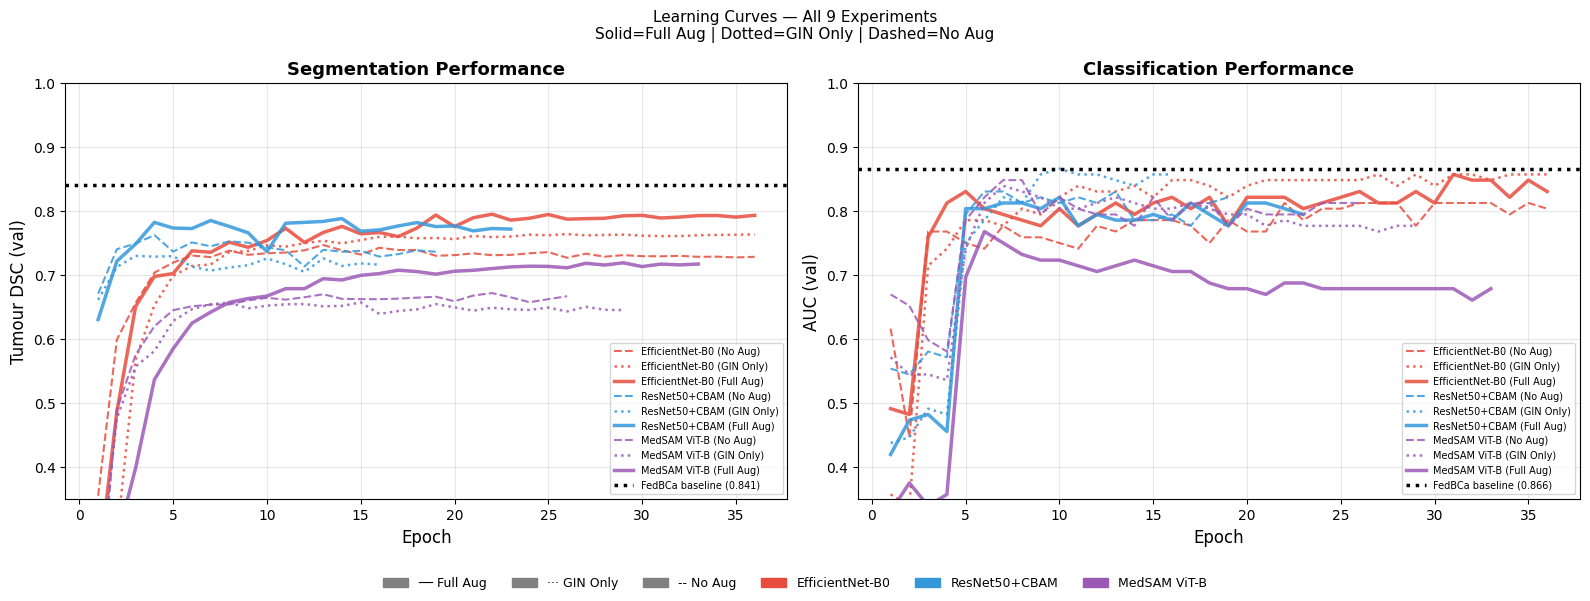

Saved: figures/learning_curves_all.png


In [6]:
# ─────────────────────────────────────────────
# CELL 5 — Learning Curves (all 9 experiments)
# ─────────────────────────────────────────────
COLORS = {
    'EfficientNet-B0': '#e74c3c',
    'ResNet50+CBAM':   '#3498db',
    'MedSAM ViT-B':    '#9b59b6',
}
STYLES = {'No Aug': '--', 'GIN Only': ':', 'Full Aug': '-'}
WIDTHS = {'No Aug': 1.5,  'GIN Only': 1.8, 'Full Aug': 2.5}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for exp_name, r in results.items():
    hist_path = EXPERIMENTS / exp_name / 'history.json'
    if not hist_path.exists(): continue
    with open(hist_path) as f: h = json.load(f)

    ep  = list(range(1, len(h.get('val_dsc', h.get('val_combined', []))) + 1))
    dsc = h.get('val_dsc', [])
    auc = h.get('val_auc', [])
    c   = COLORS.get(r['model'], '#7f8c8d')
    ls  = STYLES.get(r['aug'], '-')
    lw  = WIDTHS.get(r['aug'], 2.0)
    lbl = f"{r['model']} ({r['aug']})"

    if dsc: axes[0].plot(ep[:len(dsc)], dsc, color=c, ls=ls, lw=lw, label=lbl, alpha=0.85)
    if auc: axes[1].plot(ep[:len(auc)], auc, color=c, ls=ls, lw=lw, label=lbl, alpha=0.85)

for ax, tgt, yl, ttl in [
    (axes[0], 0.841, 'Tumour DSC (val)', 'Segmentation Performance'),
    (axes[1], 0.866, 'AUC (val)',         'Classification Performance'),
]:
    ax.axhline(tgt, color='black', ls=':', lw=2.5, label=f'FedBCa baseline ({tgt})')
    ax.set_ylabel(yl, fontsize=12)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.legend(fontsize=7, loc='lower right', ncol=1)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.35, 1.0)
    ax.set_title(ttl, fontsize=13, fontweight='bold')

# Legend for line styles
handles = [
    mpatches.Patch(color='gray', label='── Full Aug'),
    mpatches.Patch(color='gray', label='··· GIN Only'),
    mpatches.Patch(color='gray', label='-- No Aug'),
    mpatches.Patch(color=COLORS['EfficientNet-B0'], label='EfficientNet-B0'),
    mpatches.Patch(color=COLORS['ResNet50+CBAM'],   label='ResNet50+CBAM'),
    mpatches.Patch(color=COLORS['MedSAM ViT-B'],    label='MedSAM ViT-B'),
]
fig.legend(handles=handles, loc='lower center', ncol=6, fontsize=9, frameon=False)
plt.suptitle('Learning Curves — All 9 Experiments\n'
             'Solid=Full Aug | Dotted=GIN Only | Dashed=No Aug', fontsize=11)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(FIGURES / 'learning_curves_all.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/learning_curves_all.png')

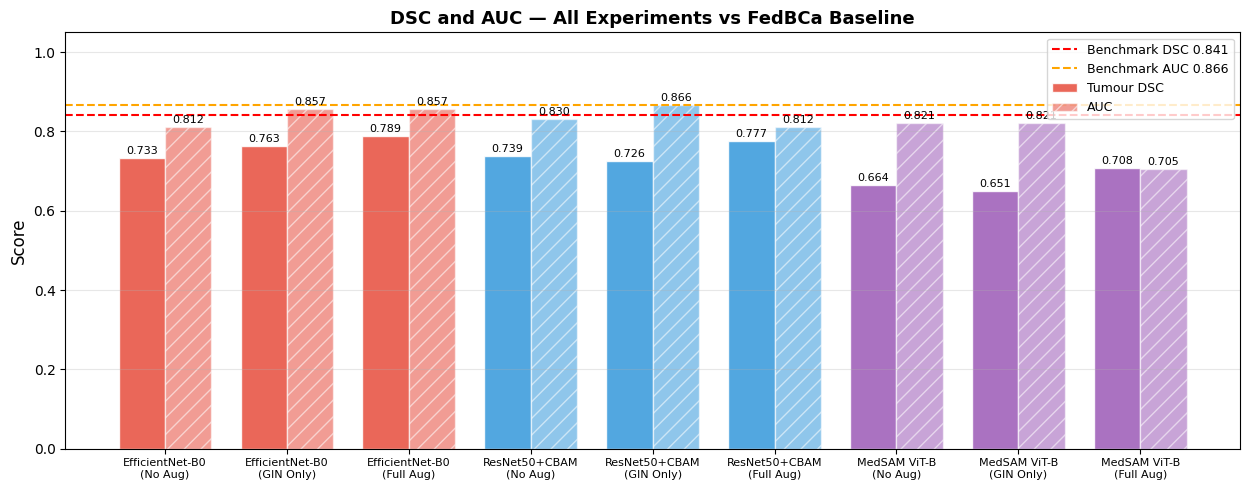

Saved: figures/bar_comparison.png


In [7]:
# ─────────────────────────────────────────────
# CELL 6 — Bar chart: DSC and AUC comparison
# ─────────────────────────────────────────────
available = [(k,v) for k,v in results.items() if v['dsc'] > 0]
if not available:
    print('No experiments completed yet.')
else:
    names = [f"{v['model']}\n({v['aug']})" for _,v in available]
    dscs  = [v['dsc'] for _,v in available]
    aucs  = [v['auc'] for _,v in available]
    colors = [COLORS.get(v['model'], '#7f8c8d') for _,v in available]

    x = np.arange(len(names))
    w = 0.38

    fig, ax = plt.subplots(figsize=(max(10, len(names)*1.4), 5))
    bars1 = ax.bar(x - w/2, dscs, w, label='Tumour DSC', color=colors, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + w/2, aucs, w, label='AUC',        color=colors, alpha=0.55, edgecolor='white', hatch='//')

    ax.axhline(0.841, color='red',    ls='--', lw=1.5, label='Benchmark DSC 0.841')
    ax.axhline(0.866, color='orange', ls='--', lw=1.5, label='Benchmark AUC 0.866')

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('DSC and AUC — All Experiments vs FedBCa Baseline', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / 'bar_comparison.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: figures/bar_comparison.png')